# Analysis of Air Disasters from 1919 to 2023

In [47]:
"""
1. Importing Libraries and Loading Data
"""

# Let's import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


file_path = "https://raw.githubusercontent.com/Alessio8-ai/Project-files/refs/heads/main/"

# Loading the dataset
df = pd.read_csv(file_path+"aviation-accidents.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [48]:
"""
2. Inspecting the Dataset to Understand What Information I Have Available
"""

# 1. Dataset size
print(f"Dataset size: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. Show first 5 rows
print("--- FIRST 5 ROWS OF THE DATASET ---")
display(df.head())

# 3. Column names and initial data types
print("\n--- INFORMATION ABOUT COLUMNS ---")
df.info()

Dataset size: 23967 rows and 9 columns.

--- FIRST 5 ROWS OF THE DATASET ---


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown



--- INFORMATION ABOUT COLUMNS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [49]:
"""
3. Identifying Missing Values, Duplicates, and Anomalies
"""

# 1. Calculate explicit missing values ​​(NaN) for each column
print("--- MISSING VALUES FOR COLUMN ---")
print(df.isnull().sum())

# 2. Calculating completely duplicated rows
print("\n--- COMPLEMENTARY DUPLICATE ROWS ---")
print(f"Number of duplicate rows detected: {df.duplicated().sum()}")

# 3. Inspecting Format Anomalies
print("\n--- SAMPLE OF UNIQUE VALUES IN THE fatalities COLUMN ---")
# We show the first 20 unique values ​​of fatalities to understand why it is read as a string (object)
print(df["fatalities"].dropna().unique()[:20])

--- MISSING VALUES FOR COLUMN ---
date               0
type               0
registration    1548
operator           4
fatalities      3938
location         948
country            0
cat                0
year               0
dtype: int64

--- COMPLEMENTARY DUPLICATE ROWS ---
Number of duplicate rows detected: 115

--- SAMPLE OF UNIQUE VALUES IN THE fatalities COLUMN ---
['0' '14' '1' '4' '2' '5' '6' '3' '7' '5+ 1' '8' '16' '12' '9' '15'
 '14+ 1' '10' '11' '35+ 9' '13']


In [50]:
"""
4. Data Type Conversion (Datetime and Numeric)
"""

# --- DATE TRANSFORMATION ---
# pd.to_datetime transforms strings into real dates.
# errors='coerce' automatically transforms 'date unk.' to NaT ((null value for dates))
df["date_clean"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")


# --- TRANSFORMATION OF VICTIMS (FATALITIES) ---
def analyze_and_sum_fatality(value):
    """
    It takes a cell from the fatalities column, cleans up the spaces,
    intercepts the presence of the '+' by adding the addends, and returns an integer.
    """
    if pd.isna(value) or str(value).strip() == "nan":
        return None

    value_str = str(value).replace(" ", " ")

    if '+' in value_str:
        parts = value_str.split('+')
        try:
            return sum(int(p) for p in parts if p != " ")
        except ValueError:
            return None
    try:
        return int(value_str)
    except ValueError:
        return None

# Convert to Int64 type (handles NaNs natively)
df["fatalities_total"] = df["fatalities"].apply(analyze_and_sum_fatality).astype("Int64")


# --- DATASET UPDATE ---
# Let's rename and clean up columns to keep the notebook tidy.
df["year_clean"] = df["date_clean"].dt.year.astype("Int64")
df.drop(columns=["date", "fatalities", "year"], inplace=True)
df.rename(columns={"date_clean": "date", "year_clean": "year"}, inplace=True)

print("Conversion complete! Here's the new data structure:")
df.info()

Conversion complete! Here's the new data structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   type              23967 non-null  object        
 1   registration      22419 non-null  object        
 2   operator          23963 non-null  object        
 3   location          23019 non-null  object        
 4   country           23967 non-null  object        
 5   cat               23967 non-null  object        
 6   date              23408 non-null  datetime64[ns]
 7   fatalities_total  20029 non-null  Int64         
 8   year              23408 non-null  Int64         
dtypes: Int64(2), datetime64[ns](1), object(6)
memory usage: 1.7+ MB


In [51]:
"""
5. Data cleaning
"""
# 1. Removing duplicates
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
rows_removed = initial_rows - df.shape[0]

print(f"Duplicate detection completed.")
print(f"- Rows removed: {rows_removed}")
print(f"- Remaining rows in the dataset: {df.shape[0]}")

Duplicate detection completed.
- Rows removed: 118
- Remaining rows in the dataset: 23849


In [52]:
# List of text columns to normalize
text_columns = ["type", "operator", "location", "country", "cat"]

for column in text_columns:
    # We convert to string and apply stripping to remove white space at the edges
    df[column] = df[column].astype(str).str.strip()

# We replace any 'nan' strings resulting from the forced string conversion with the actual null value.
df.replace("nan", np.nan, inplace=True)

print("Text normalization complete. Sample of the first 3 clean rows:")
display(df.head(3))

Text normalization complete. Sample of the first 3 clean rows:


,type,registration,operator,location,country,cat,date,fatalities_total,year
0,Antonov An-12B,T-1206,Indonesian AF,NaN,Unknown country,U1,NaT,<NA>,<NA>
1,Antonov An-12B,T-1204,Indonesian AF,NaN,Unknown country,U1,NaT,<NA>,<NA>
2,Antonov An-12B,T-1201,Indonesian AF,NaN,Unknown country,U1,NaT,<NA>,<NA>


In [53]:
"""
6. Creating two Derived Columns: Day of Week and Decade
"""

# 1. Weekday extraction (0 = Monday, 6 = Sunday)
days_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday",
    3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
}
df["day_of_week"] = df["date"].dt.weekday.map(days_map)

# 2. Calculating the decade of membership
df["decade"] = (df["year"] // 10) * 10
df["decade"] = df["decade"].astype("Int64") # We keep the integer format with NaN support

print("Feature Engineering completed successfully. Columns added: day_of_week, decade.")
print("Preview of the new fields:")
display(df[["date", "year", "day_of_week", "decade"]].dropna().head(3))

Feature Engineering completed successfully. Columns added: day_of_week, decade.
Preview of the new fields:


,date,year,day_of_week,decade
61,1919-08-02,1919,Saturday,1910
62,1919-08-11,1919,Monday,1910
63,1920-02-23,1920,Monday,1920


--- DESCRIPTIVE STATISTICS: TOTAL VICTIMS ---
count      20018.0
mean      6.630133
std      23.957095
min            0.0
25%            0.0
50%            0.0
75%            5.0
max         1692.0
Name: fatalities_total, dtype: Float64


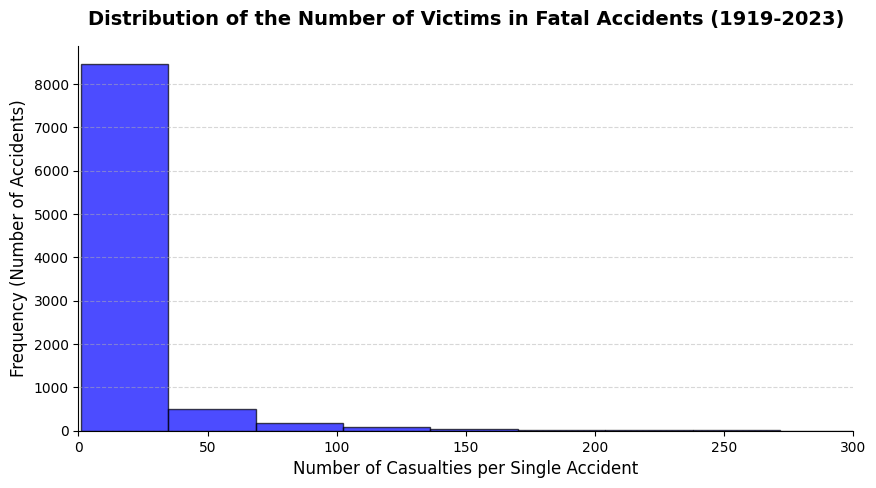

In [54]:
"""
7. Distribution Analysis of Victims
"""

# 1. General descriptive statistics (including zeros)
print("--- DESCRIPTIVE STATISTICS: TOTAL VICTIMS ---")
print(df["fatalities_total"].describe())

# 2. Let's prepare the data for the graph: let's isolate the fatal accidents (> 0 victims)
fatal_accidents = df[df["fatalities_total"] > 0]["fatalities_total"].dropna()

# 3. Graph construction with Matplotlib
plt.figure(figsize=(10, 5))
plt.hist(fatal_accidents, bins=50, color="blue", edgecolor="black", alpha=0.7)

# Aesthetic optimization of the graph
plt.title("Distribution of the Number of Victims in Fatal Accidents (1919-2023)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Number of Casualties per Single Accident", fontsize=12)
plt.ylabel("Frequency (Number of Accidents)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# We limit the X-axis for better readability, since the extremes (outliers) would squash the graph.
plt.xlim(0, 300)

# Removing the top and right edges
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

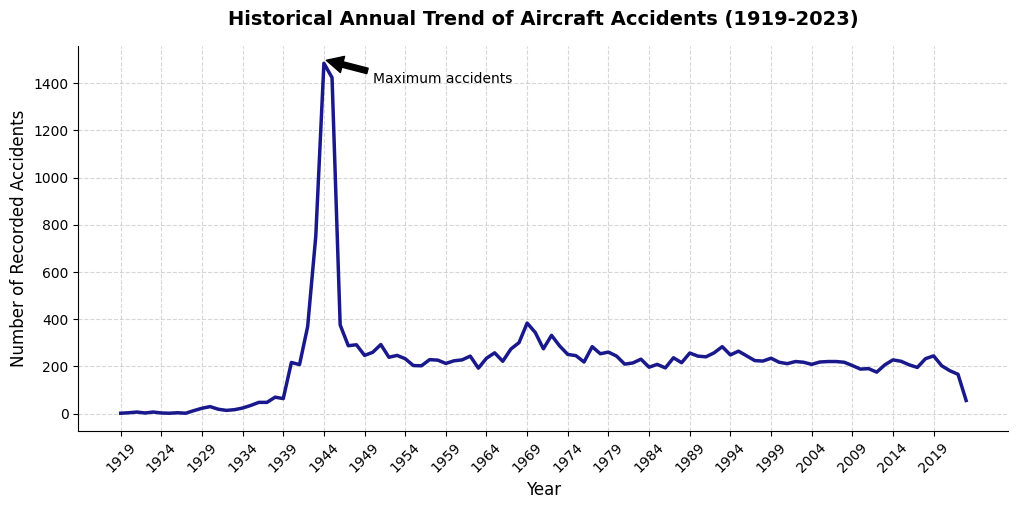

In [55]:
"""
8. Historical Trend Analysis of Accidents
"""

# Grouping by year and counting of accidents
accidents_per_year = df.groupby("year").size()

plt.figure(figsize=(12, 5))
plt.plot(accidents_per_year.index, accidents_per_year.values, color="Navy", alpha=0.9, linewidth=2.5, label="Incidenti Totali")

# X-axis with a tick every 5 years
plt.xticks(range(int(accidents_per_year.index.min()), int(accidents_per_year.index.max()) + 1, 5), rotation=45)

# Graphic enrichment
plt.title("Historical Annual Trend of Aircraft Accidents (1919-2023)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Recorded Accidents", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.annotate("Maximum accidents", xy=(1944, 1500), xytext=(1950, 1400), arrowprops=dict(facecolor="black", shrink=0.05))

# Cleaning the axes
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

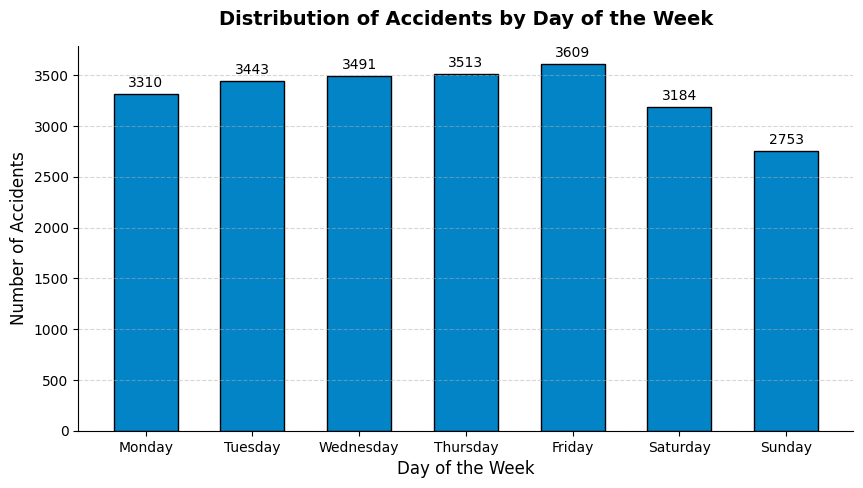

In [56]:
"""
9. Weekly Incident Frequency Analysis
"""

# Accident count by day of the week
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
accidents_day = df["day_of_week"].value_counts().reindex(order_days)

plt.figure(figsize=(10, 5))
bars = plt.bar(accidents_day.index, accidents_day.values, color="#0284C7", edgecolor="black", width=0.6)

plt.title("Distribution of Accidents by Day of the Week", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adding the number above each bar
ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10)

# Cleaning the axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

--- STRUCTURAL COMPARISON METRICS ---
Annual average accidents PRE-11/09: 234.5
Annual average accidents POST-11/09: 201.5(14.1%) reduction
Average fatality rate per single accident PRE-11/09: 7.89 victims
Average fatality rate per single incident POST-11/09: 3.78 victims



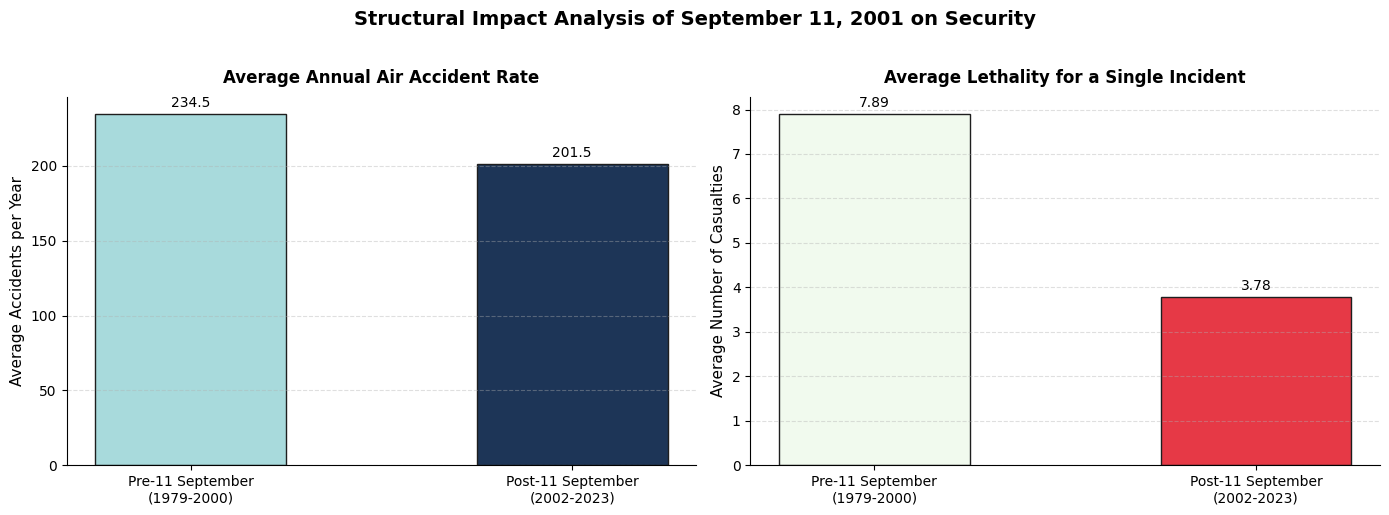

In [57]:
"""
10. Analysis of the Impact of September 11, 2001 on Aviation Safety

    To measure long-term effectiveness, we analyze the trend by isolating a symmetrical 22-year time window.
"""


# We create filters for the two symmetric periods of 22 years
pre_period = df[(df["year"] >= 1979) & (df["year"] <= 2000)]
post_period = df[(df["year"] >= 2002) & (df["year"] <= 2023)]

# Calculating metrics for the PRE period (1979-2000)
pre_years = 22
accidents_tot_pre = len(pre_period)
average_accidents_pre_year = accidents_tot_pre / pre_years
average_lethality_pre = pre_period["fatalities_total"].mean()

# Calculating metrics for the POST period (2002-2023)
post_years = 22
accidents_tot_post = len(post_period)
average_accidents_post_year = accidents_tot_post / post_years
average_lethality_post = post_period["fatalities_total"].mean()

# Viewing calculated KPIs
print("--- STRUCTURAL COMPARISON METRICS ---")
print(f"Annual average accidents PRE-11/09: {average_accidents_pre_year:.1f}")
print(f"Annual average accidents POST-11/09: {average_accidents_post_year:.1f}"
      f"({((average_accidents_pre_year-average_accidents_post_year)/average_accidents_pre_year)*100:.1f}%) reduction")
print(f"Average fatality rate per single accident PRE-11/09: {average_lethality_pre:.2f} victims")
print(f"Average fatality rate per single incident POST-11/09: {average_lethality_post:.2f} victims\n")

# Construction of the visual comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Annual Average Accidents
periods_label = ["Pre-11 September\n(1979-2000)", "Post-11 September\n(2002-2023)"]
bars = ax1.bar(periods_label, [average_accidents_pre_year, average_accidents_post_year], color=["#a8dadc", "#1d3557"], width=0.5, edgecolor="#1E1E1E")
ax1.set_title("Average Annual Air Accident Rate", fontsize=12, fontweight="bold", pad=10)
ax1.set_ylabel("Average Accidents per Year", fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
ax1.bar_label(bars, fmt="%.1f", padding=3, fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Graph 2: Average lethality per event
bars = ax2.bar(periods_label, [average_lethality_pre, average_lethality_post], color=["#f1faee", "#e63946"], width=0.5, edgecolor="#1E1E1E")
ax2.set_title("Average Lethality for a Single Incident", fontsize=12, fontweight="bold", pad=10)
ax2.set_ylabel("Average Number of Casualties", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
ax2.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Structural Impact Analysis of September 11, 2001 on Security", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Geographic Analysis: Accident Volume and Severity by Country

In which area of ​​the world were the most events recorded? And where were the accidents most lethal on average?
To answer the IASS's questions, let's isolate the Top 10 nations in terms of overall number of accidents. We will combine this metric with the calculation of average lethality (average number of victims per single incident) to verify whether a high volume of events always corresponds to a high severity.

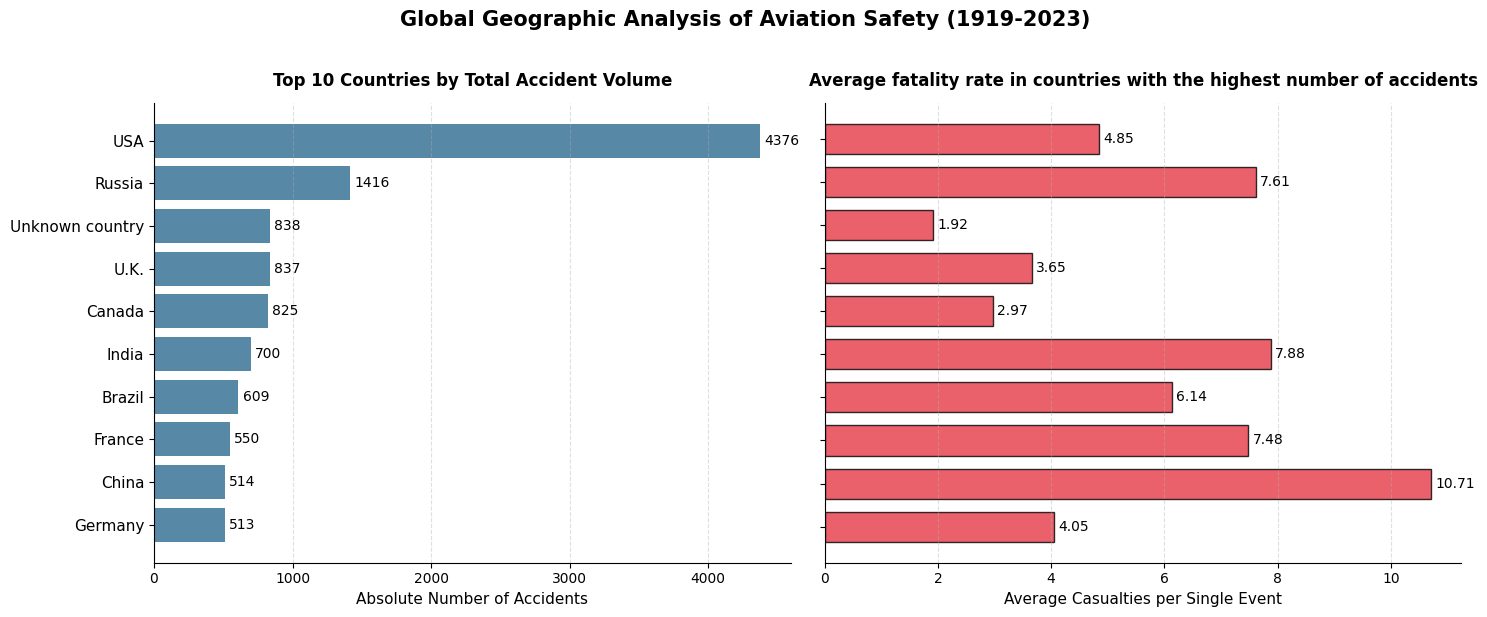

In [58]:
"""
11. Geographic Analysis: Top 10 Countries by Accident Volume
"""

# 1. Data aggregation by country
country_analysis = df.groupby("country").agg(
    number_of_accidents=("type", "count"),
    average_lethality=("fatalities_total", "mean")
).sort_values(by="number_of_accidents", ascending=False)

# Let's isolate the Top 10 by accident volume
top_10_countries = country_analysis.head(10)

# 2. Construction of the horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Top 10 Countries by Accident Volume
y_pos = range(len(top_10_countries))
bars = ax1.barh(y_pos, top_10_countries["number_of_accidents"], color="#457b9d", alpha=0.9)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_10_countries.index, fontsize=11)
ax1.invert_yaxis()  # Show the country with the most accidents at the top
ax1.set_title("Top 10 Countries by Total Accident Volume", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Absolute Number of Accidents", fontsize=11)
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax = plt.gca()
ax1.bar_label(bars, padding=3, fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Graph 2: Average lethality in the same 10 countries
bars = ax2.barh(y_pos, top_10_countries["average_lethality"], color="#e63946", alpha=0.8, edgecolor="black", height=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([]) # Let's hide the texts on the central Y-axis so as not to duplicate them
ax2.invert_yaxis()
ax2.set_title("Average fatality rate in countries with the highest number of accidents", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Average Casualties per Single Event", fontsize=11)
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax = plt.gca()
ax2.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Global Geographic Analysis of Aviation Safety (1919-2023)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

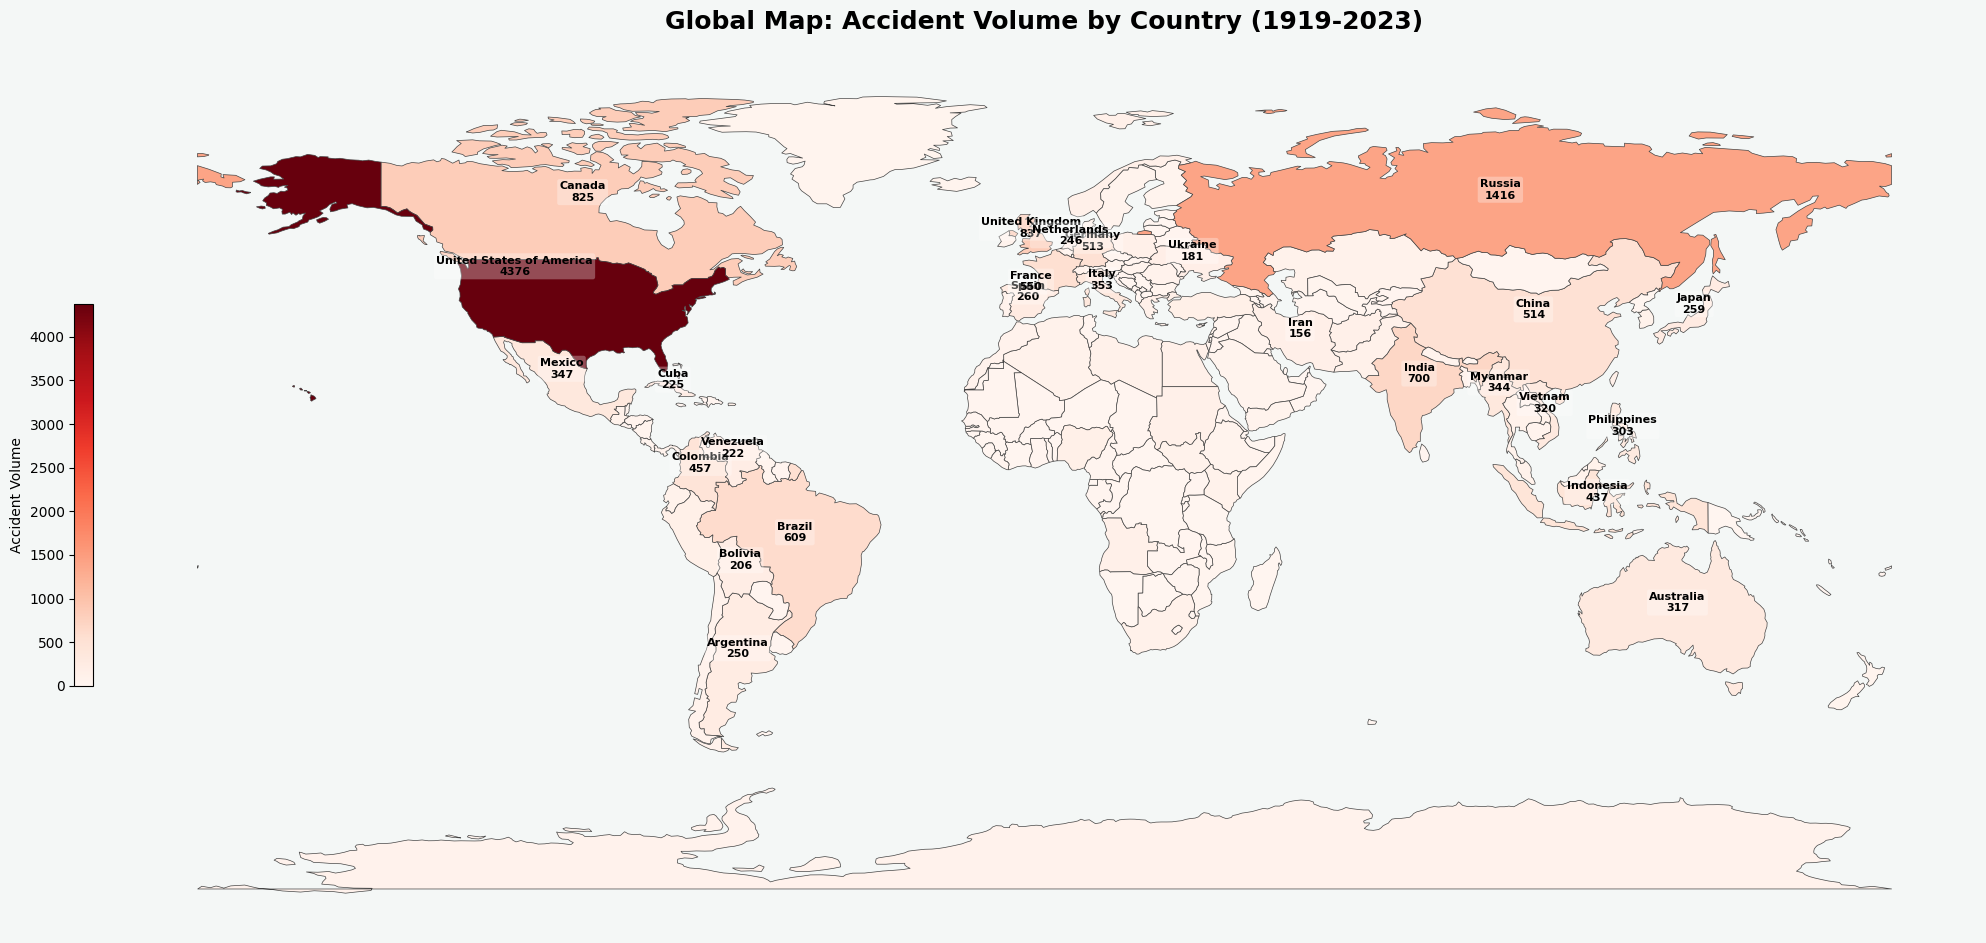

In [59]:
"""
12. Global Aircraft Accident Map
"""

# 1. Loading global geometries
url_geojson = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(url_geojson)

# In GeoJSON, countries are identified in the 'name' column (e.g., "United States of America")
# We permanently align our main dataset to ensure matching
alignment_map = {
    "USA": "United States of America",
    "United States": "United States of America",
    "U.K.": "United Kingdom",
    "United Kingdom": "United Kingdom"
}
df["country_map"] = df["country"].replace(alignment_map)

# 2. Data aggregation
accidents_by_country = df["country_map"].value_counts().reset_index()
accidents_by_country.columns = ["name", "number_of_accidents"]

# 3. Geometry Union
final_map = world.merge(accidents_by_country, on="name", how="left")
final_map["number_of_accidents"] = final_map["number_of_accidents"].fillna(0)

# 4. Viewing
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.set_facecolor("#f4f7f6")
fig.patch.set_facecolor("#f4f7f6")

# Generate map with legend
final_map.plot(
    column="number_of_accidents",
    cmap="Reds",
    linewidth=0.5,
    ax=ax,
    edgecolor="#444444",
    legend=True,
    legend_kwds={
        "label": "Accident Volume",
        "orientation": "vertical",
        "shrink": 0.4,
        "pad": 0.01,
        "aspect": 20,
        "fraction": 0.02,
        "location": "left" # Place the ladder on the left inside the axis
    }
)

# 5. Added labels for countries with the most accidents
for idx, row in final_map.iterrows():
    if row["number_of_accidents"] > 150:
        centroid = row.geometry.centroid
        ax.annotate(text=f"{row["name"]}\n{int(row["number_of_accidents"])}",
                    xy=(centroid.x, centroid.y),
                    horizontalalignment="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.3, ec="none"))

# Title and cleanliness
ax.set_title("Global Map: Accident Volume by Country (1919-2023)", fontsize=18, fontweight="bold", pad=20)
ax.axis("off")

plt.tight_layout()
plt.show()

--- SUMMARY TABLE BY ASN CATEGORY ---


,counting,total_victims,average_victims
cat,,,
A1,17316,119680,8.338907
A2,2494,155,0.062728
C1,1181,8983,9.299172
H2,1049,181,0.173206
O1,1032,75,0.079787
U1,571,0,0.0
C2,84,54,0.642857
O2,65,2,0.03125
H1,42,3592,85.52381


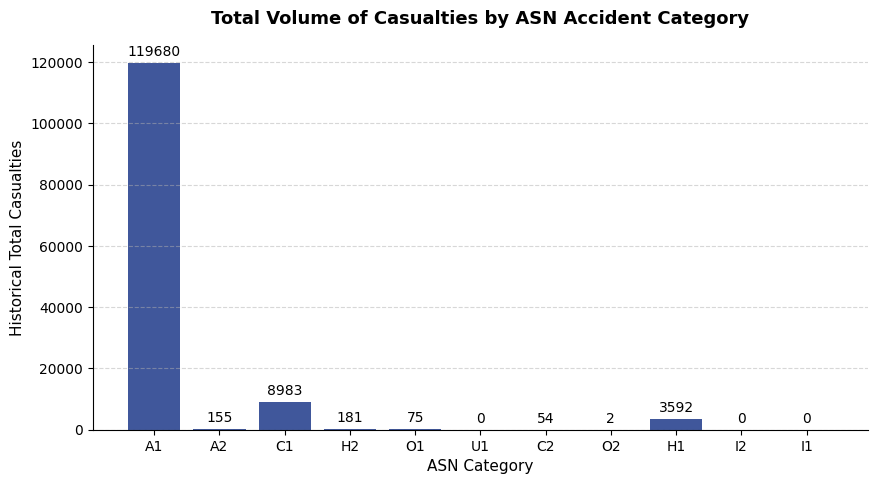

In [60]:
"""
13. Accident Category Analysis
"""

# Grouping by ASN category
cat_analysis = df.groupby("cat").agg(
    counting=("type", "count"),
    total_victims=("fatalities_total", "sum"),
    average_victims=("fatalities_total", "mean")
).sort_values(by="counting", ascending=False)

print("--- SUMMARY TABLE BY ASN CATEGORY ---")
display(cat_analysis)

# Bar chart to understand the visual impact of categories on total casualties
plt.figure(figsize=(10, 5))
bars = plt.bar(cat_analysis.index, cat_analysis["total_victims"], color="#1E3A8A", alpha=0.85)

plt.title("Total Volume of Casualties by ASN Accident Category", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("ASN Category", fontsize=11)
plt.ylabel("Historical Total Casualties", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

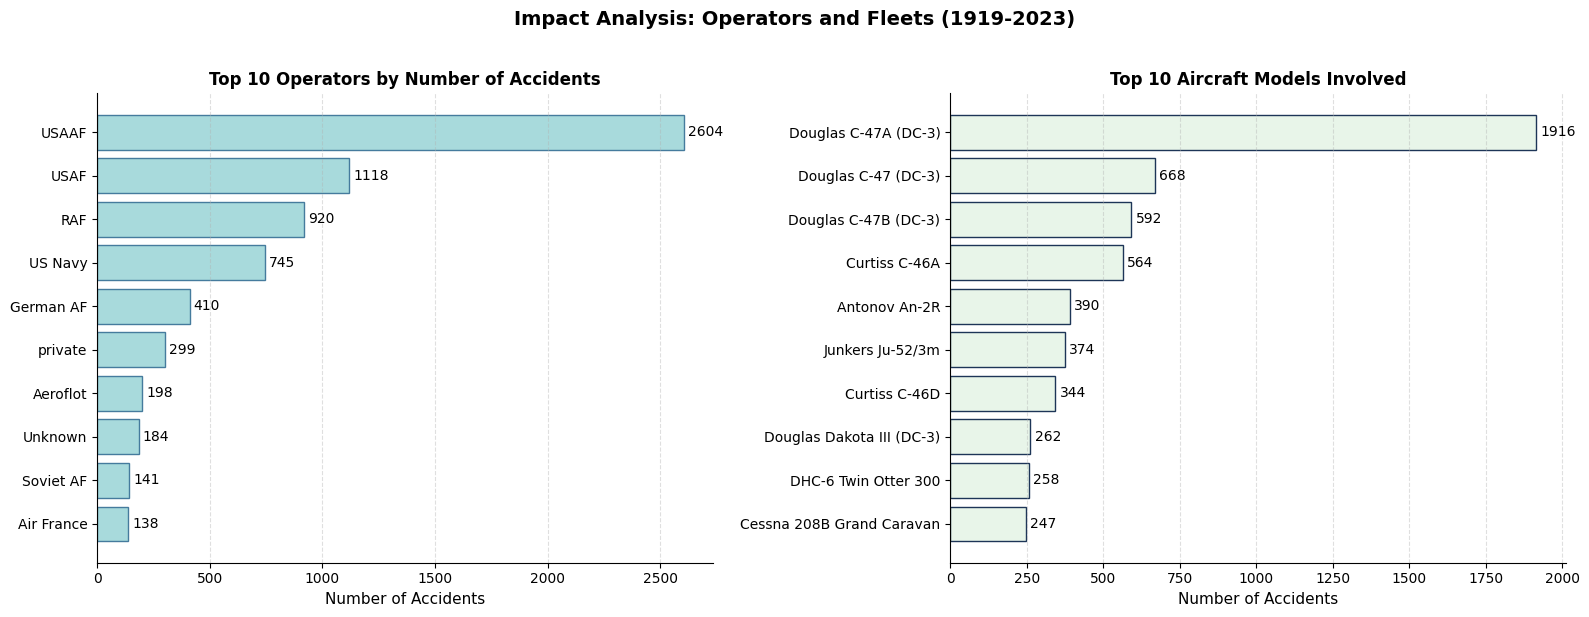

In [61]:
"""
14. Operator Analysis and Aircraft Models
"""

# 1. Top 10 Operators with the Most Recorded Accidents
top_operators = df["operator"].value_counts().head(10)

# 2. Top 10 Aircraft Models Involved in Accidents
top_aircraft = df["type"].value_counts().head(10)

# Building side-by-side charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Operators Chart
y_ops = range(len(top_operators))
bars = ax1.barh(y_ops, top_operators.values, color="#a8dadc", edgecolor="#457b9d")
ax1.set_yticks(y_ops)
ax1.set_yticklabels(top_operators.index, fontsize=10)
ax1.invert_yaxis()
ax1.set_title("Top 10 Operators by Number of Accidents", fontsize=12, fontweight="bold")
ax1.set_xlabel("Number of Accidents", fontsize=11)
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax = plt.gca()
ax1.bar_label(bars, padding=3, fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Aircraft Chart
y_vel = range(len(top_aircraft))
bars = ax2.barh(y_vel, top_aircraft.values, color="#E8F5E9", edgecolor="#1d3557")
ax2.set_yticks(y_vel)
ax2.set_yticklabels(top_aircraft.index, fontsize=10)
ax2.invert_yaxis()
ax2.set_title("Top 10 Aircraft Models Involved", fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Accidents", fontsize=11)
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax = plt.gca()
ax2.bar_label(bars, padding=3, fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Impact Analysis: Operators and Fleets (1919-2023)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 15. Conclusions

At the end of this Exploratory Data Analysis on the global history of aircraft accidents from 1919 to 2023, we have extracted four key information pillars:

1. **Volume vs. Lethality:**

   The United States has the highest absolute number of historical incidents in the dataset. However, analysis of average lethality reveals that the vast majority of these events caused very few or no casualties. Conversely, countries with significantly lower accident volumes show much higher average fatality rates.

2. **Historical and Technological Evolution:**

   Excluding the historical period of the Second World War, the trend in accidents shows a clear peak in the second half of the twentieth century (a phase of very strong expansion of commercial flight with technologies that were not yet mature). Over the past few decades, a steady and drastic decline in the number of accidents has been observed, a remarkable achievement when compared to the exponential increase in global commercial flights over the same period.

3. **Post-9/11 Structural Impact:**

   A symmetrical comparison of the 22 years before and after September 11, 2001, demonstrates the effectiveness of the global security protocols introduced after the attack. In the period 2002-2023, there was a reduction in the annual average number of accidents and a sharp decline in the average lethality of events.

4. **The Impact of Large Historical Operators:**

   The data shows that the rankings of the most frequently involved operators and aircraft are dominated by historical, military, or former Soviet Union-related entities (e.g., historic Aeroflot, state air forces).